In [1]:
import os
import sys
import torch

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '3'

In [3]:
from sklearn.metrics.pairwise import pairwise_distances
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from scipy import stats
from tqdm.notebook import tqdm
from RTD_Lite import RTD_Lite, RTD_Lite_summ_only
%matplotlib inline

In [4]:
import barcodes

In [5]:
import pickle
from cka import cka
#from msid import msid_score
from svcca import svcca

def msid_score_n(a, b, n):
    total = 0.0
    for _ in range(n):
        total += 0 #msid_score(a, b)
    return total / n

### Exp many clusters

In [6]:
np.random.seed(7)

all_clusters = []

for i in range(60):
    all_clusters.append(np.random.multivariate_normal(np.zeros(2), np.eye(2), 5))
    
A_base = np.concatenate(all_clusters)

In [7]:
def split2clusters(k):
    
    if k == 1:
        return A_base
    
    arr = []
    
    for i in range(60):
        idx = i % k
    
        theta = 2 * np.pi * idx / k
        d = np.array([np.cos(theta), np.sin(theta)]) * 10
        
        arr.append(all_clusters[i] + d)
        
    A_mod = np.concatenate(arr)
    
    return A_mod

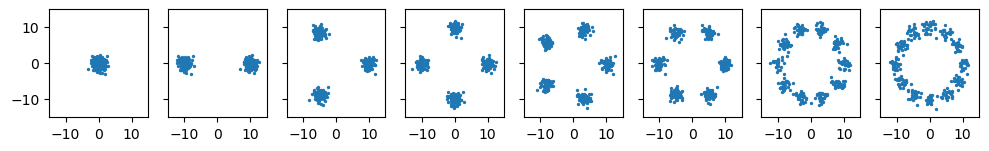

In [8]:
ALL = [2, 3, 4, 5, 6, 10, 12]

fig, ax = plt.subplots(1, len(ALL) + 1)
fig.set_size_inches(12, 1.4)

for idx, k in enumerate([0] + ALL):
    
    if idx == 0:
        A = A_base
    else:
        A = split2clusters(k)

    ax[idx].scatter(x = A[:,0], y = A[:,1], s = 2)
    ax[idx].set_xlim(-15, 15)
    ax[idx].set_ylim(-15, 15)
    
for ax in fig.get_axes():
    ax.label_outer()

H0: num barcodes 0
H1: num barcodes 365
max0,976Barcode 1 = 0.15785135328769684
maxBarcode 1 = 0.3863179236650467
middleBarcode 1 = 0.04139025928452611


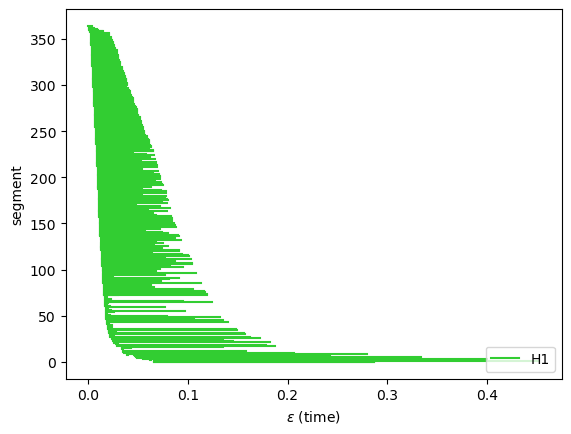

H0: num barcodes 0
H1: num barcodes 76
max0,976Barcode 1 = 0.13873417675495148
maxBarcode 1 = 0.6603498747572303
middleBarcode 1 = 0.03663717210292816


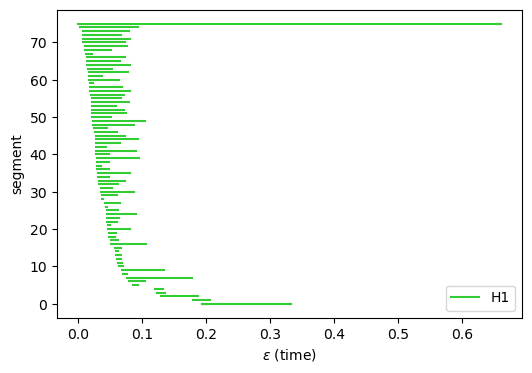

H0: num barcodes 0
H1: num barcodes 367
max0,976Barcode 1 = 0.1640744637697935
maxBarcode 1 = 0.3638271912932396
middleBarcode 1 = 0.04423673823475838


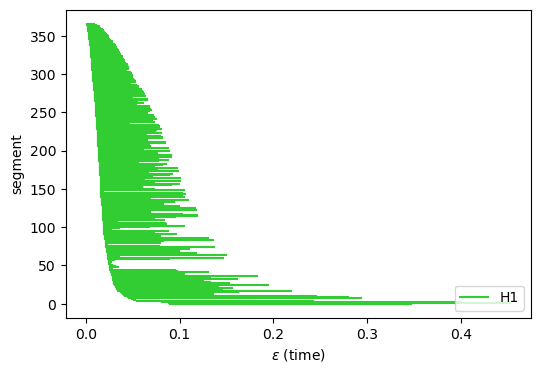

H0: num barcodes 0
H1: num barcodes 121
max0,976Barcode 1 = 0.12647380866110325
maxBarcode 1 = 0.6501727988943458
middleBarcode 1 = 0.037982162088155746


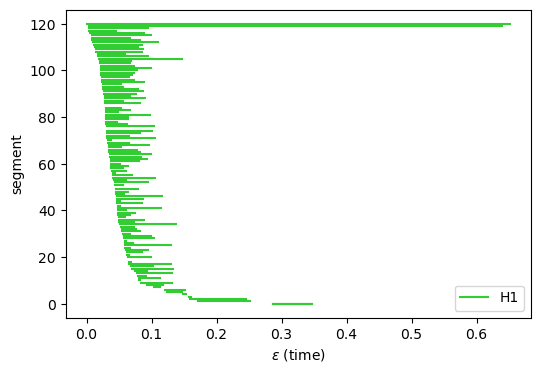

H0: num barcodes 0
H1: num barcodes 351
max0,976Barcode 1 = 0.17009194567799568
maxBarcode 1 = 0.36300163716077805
middleBarcode 1 = 0.0521748224273324


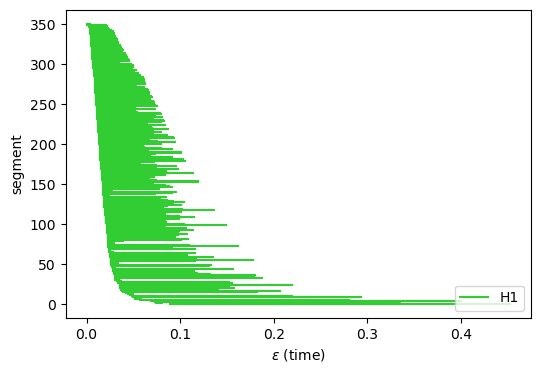

H0: num barcodes 0
H1: num barcodes 166
max0,976Barcode 1 = 0.14545155223459005
maxBarcode 1 = 0.4314445247873664
middleBarcode 1 = 0.04036908596754074


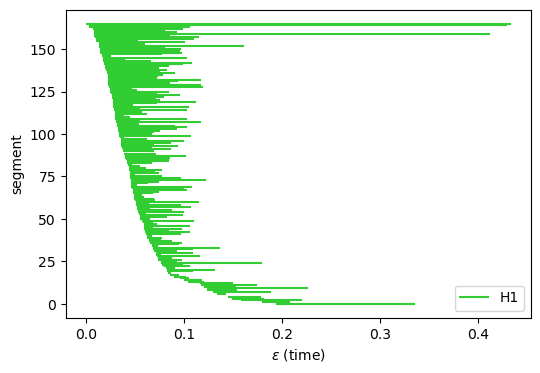

H0: num barcodes 0
H1: num barcodes 351
max0,976Barcode 1 = 0.1947704367339611
maxBarcode 1 = 0.38598938286304474
middleBarcode 1 = 0.05504344031214714


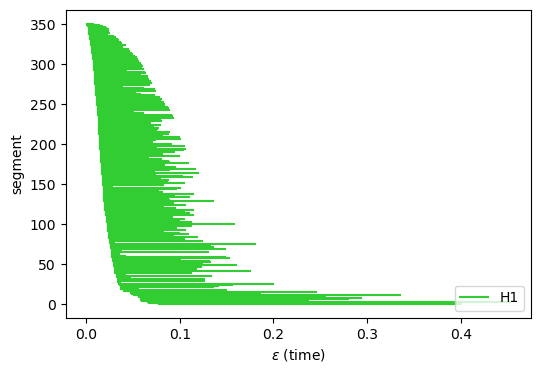

H0: num barcodes 0
H1: num barcodes 185
max0,976Barcode 1 = 0.14061769284307957
maxBarcode 1 = 0.3968004046473652
middleBarcode 1 = 0.04255976527929306


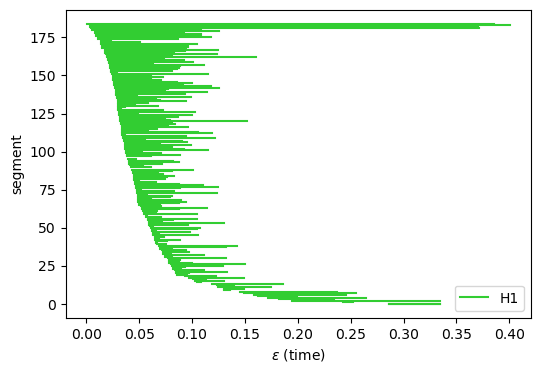

H0: num barcodes 0
H1: num barcodes 345
max0,976Barcode 1 = 0.172812320291996
maxBarcode 1 = 0.3690713569521904
middleBarcode 1 = 0.05819182097911835


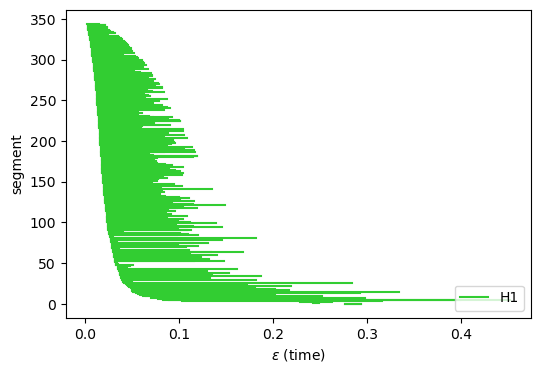

H0: num barcodes 0
H1: num barcodes 208
max0,976Barcode 1 = 0.24176747119054198
maxBarcode 1 = 0.2916533707175404
middleBarcode 1 = 0.04278586804866791


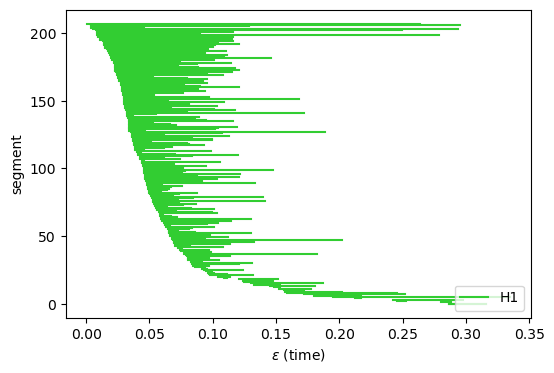

H0: num barcodes 0
H1: num barcodes 335
max0,976Barcode 1 = 0.19690141454339027
maxBarcode 1 = 0.35931768268346786
middleBarcode 1 = 0.06788846664130688


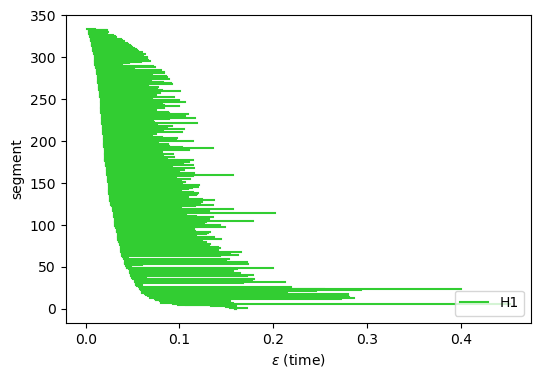

H0: num barcodes 0
H1: num barcodes 255
max0,976Barcode 1 = 0.14720224682241678
maxBarcode 1 = 0.16716635134071112
middleBarcode 1 = 0.05202731490135193


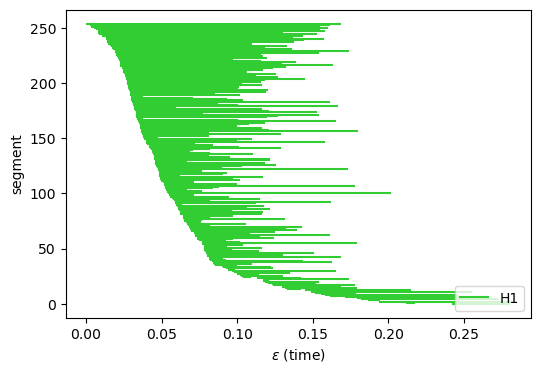

H0: num barcodes 0
H1: num barcodes 343
max0,976Barcode 1 = 0.1553276926279068
maxBarcode 1 = 0.3477803245186806
middleBarcode 1 = 0.07018075045198202


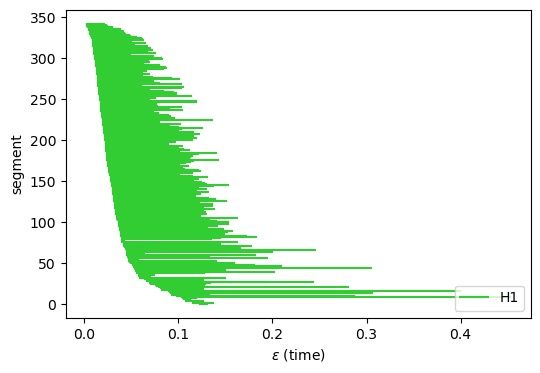

H0: num barcodes 0
H1: num barcodes 273
max0,976Barcode 1 = 0.13041241466999054
maxBarcode 1 = 0.15407826378941536
middleBarcode 1 = 0.0521733071655035


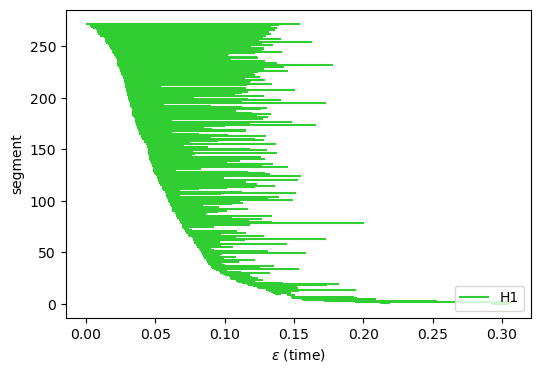

CPU times: user 49.9 s, sys: 2.14 s, total: 52 s
Wall time: 36 s


In [11]:
%%time
res1 = []
res2 = []
res_cka = []
res_imd = []
res_svcca = []
res_rtd_lite1 = []

barcs1 = []
barcs2 = []

barcs_rtd_lite1 = []

for i, k in enumerate(ALL):
    
    A_mod = split2clusters(k)
    
    barc = barcodes.calc_embed_dist(A_base, A_mod, norm = 'quantile')
    barcodes.plot_barcodes(barcodes.barc2array(barc), title = '')
    plt.show()
    res1.append(barcodes.h1sum(barc))
    barcs1.append(barc)

    barc = barcodes.calc_embed_dist(A_mod, A_base, norm = 'quantile')
    barcodes.plot_barcodes(barcodes.barc2array(barc), title = '')
    plt.show()
    res2.append(barcodes.h1sum(barc))
    barcs2.append(barc)
    
    res_cka.append(cka(A_base, A_mod))
    res_imd.append(msid_score_n(A_base, A_mod, 100))    
    res_svcca.append(svcca(A_base.T, A_mod.T))
    res_rtd_lite1.append(RTD_Lite_summ_only(torch.tensor(A_base), torch.tensor(A_mod))())
    
    barcs_rtd_lite1.append(RTD_Lite(torch.tensor(A_base), torch.tensor(A_mod))())

In [13]:
barc

{0: array([], dtype=float64),
 1: array([(0.2930708 , 0.30441722), (0.21254362, 0.21841773),
        (0.19474392, 0.3056152 ), (0.17207345, 0.25206256),
        (0.15740027, 0.20179728), (0.15590833, 0.20872037),
        (0.14950956, 0.19474669), (0.14868683, 0.19284534),
        (0.14553925, 0.14979969), (0.13726111, 0.13967583),
        (0.13525431, 0.14719705), (0.13397367, 0.14128073),
        (0.13289239, 0.15285875), (0.13050194, 0.1936697 ),
        (0.12513244, 0.12576212), (0.12456689, 0.15249372),
        (0.12386131, 0.1262081 ), (0.12098761, 0.15162839),
        (0.1175743 , 0.1731524 ), (0.11658706, 0.18192849),
        (0.11354821, 0.14128073), (0.11011463, 0.12135718),
        (0.10883937, 0.11158402), (0.10861852, 0.12690784),
        (0.1054039 , 0.11360026), (0.104557  , 0.12363937),
        (0.10446773, 0.11873559), (0.10401178, 0.11348398),
        (0.10066789, 0.11741213), (0.09921544, 0.10008048),
        (0.09756937, 0.13211082), (0.09711336, 0.11097864),
       

H0: num barcodes 13
max0,976Barcode 0 = 0.6603498927052769
maxBarcode 0 = 0.6603498927052769
middleBarcode 0 = 0.0020600017674138986


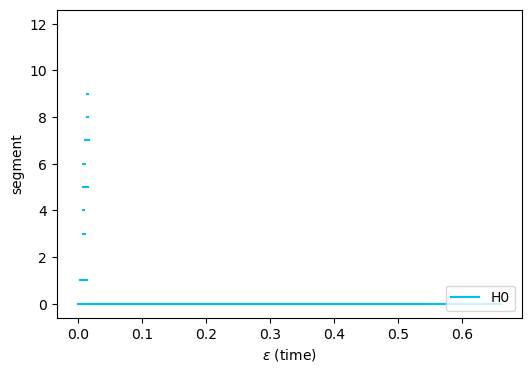

In [21]:
barc_lite = {0: barcs_rtd_lite1[0]['2->1'].numpy()}
barcodes.plot_barcodes(barcodes.barc2array(barc_lite), title = '')

H0: num barcodes 288
max0,976Barcode 0 = 0.15669726278472126
maxBarcode 0 = 0.3863179304781539
middleBarcode 0 = 0.03955836353870894


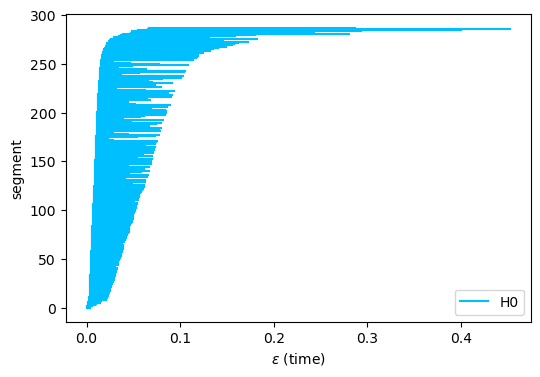

In [65]:
#pickle.dump((res1, res2, res_cka), open('exp_clusters.pickle', 'wb'))
#(res1, res2, res_cka) = pickle.load(open('exp_clusters.pickle', 'rb'))

In [66]:
clusters2show

[2, 3, 4, 5, 6, 10, 12]

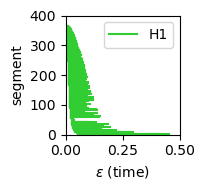

In [84]:
clusters2show = ALL
clusters2show = [3]
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    
    i = ALL.index(k)
    barc = barcs1[i]
    ax.set_ylim(0, 400)
    ax.set_xlim(0, 0.5)
    barcodes.plot_barcodes(barcodes.barc2array(barc), title = '', ax = ax, fig = fig)
    
    ax.legend(loc = 'best')
    
fig.tight_layout()
plt.show()

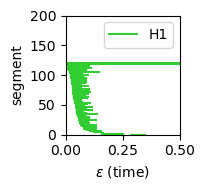

In [88]:
clusters2show = ALL
clusters2show = [3]
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    
    i = ALL.index(k)
    barc = barcs2[i]
    ax.set_ylim(0, 200)
    ax.set_xlim(0, 0.5)
    barcodes.plot_barcodes(barcodes.barc2array(barc), title = '', ax = ax, fig = fig)
    
    ax.legend(loc = 'best')
    
fig.tight_layout()
plt.show()

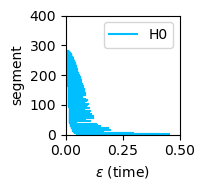

In [86]:
clusters2show = ALL
clusters2show = [3]
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    
    i = ALL.index(k)
    barc = barcs1[i]
    ax.set_ylim(0, 400)
    ax.set_xlim(0, 0.5)
    barc_lite = {0: np.array(sorted([x for x in barcs_rtd_lite1[i]['1->2'].numpy()], key = lambda x : -x[0]))}
    barcodes.plot_barcodes(barcodes.barc2array(barc_lite), title = '', ax = ax, fig = fig)
    
    ax.legend(loc = 'best')
    
fig.tight_layout()
plt.show()

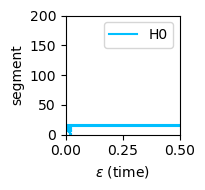

In [89]:
clusters2show = ALL
clusters2show = [3]
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    
    i = ALL.index(k)
    barc = barcs1[i]
    ax.set_ylim(0, 200)
    ax.set_xlim(0, 0.5)
    barc_lite = {0: np.array(sorted([x for x in barcs_rtd_lite1[i]['2->1'].numpy()], key = lambda x : -x[0]))}
    barcodes.plot_barcodes(barcodes.barc2array(barc_lite), title = '', ax = ax, fig = fig)
    
    ax.legend(loc = 'best')
    
fig.tight_layout()
plt.show()

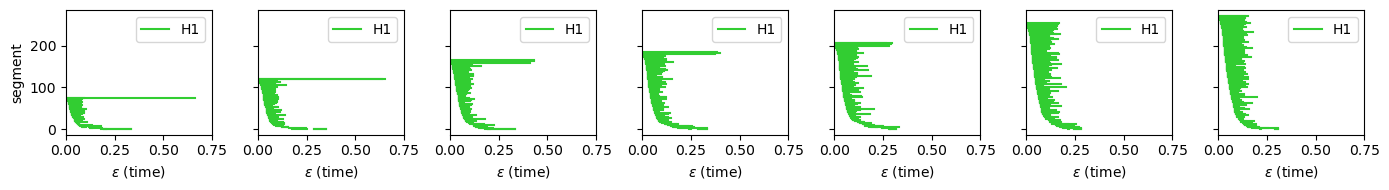

In [64]:
clusters2show = ALL
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    i = ALL.index(k)
    barc = barcs2[i]
    #ax[col].set_ylim(0, 300)
    ax[col].set_xlim(0, 0.75)
    barcodes.plot_barcodes(barcodes.barc2array(barc), title = '', ax = ax[col], fig = fig)
    
    if col > 0:
        ax[col].set_ylabel('')
        
    ax[col].legend(loc = 'best')
    
fig.tight_layout()
plt.show()

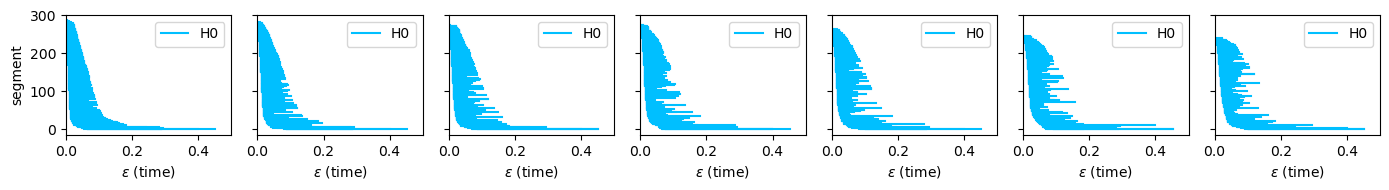

In [90]:
clusters2show = ALL
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    i = ALL.index(k)
    barc = barcs1[i]
    #ax[col].set_ylim(0, 300)
    ax[col].set_xlim(0, 0.5)
    #barcodes.plot_barcodes(barcodes.barc2array(barc), title = '', ax = ax[col], fig = fig)
    barc_lite = {0: np.array(sorted([x for x in barcs_rtd_lite1[i]['1->2'].numpy()], key = lambda x : -x[0]))}
    barcodes.plot_barcodes(barcodes.barc2array(barc_lite), title = '', ax = ax[col], fig = fig)
    
    if col > 0:
        ax[col].set_ylabel('')
        
    ax[col].legend(loc = 'best')
    
fig.tight_layout()
plt.show()

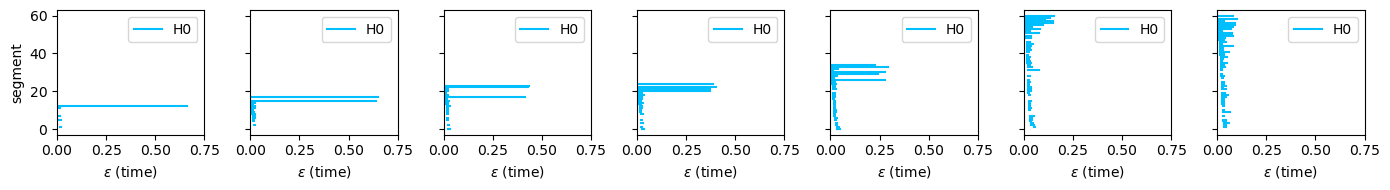

In [63]:
clusters2show = ALL
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    i = ALL.index(k)
    barc = barcs1[i]
    #ax[col].set_ylim(0, 300)
    ax[col].set_xlim(0, 0.75)
    #barcodes.plot_barcodes(barcodes.barc2array(barc), title = '', ax = ax[col], fig = fig)
    barc_lite = {0: np.array(sorted([x for x in barcs_rtd_lite1[i]['2->1'].numpy()], key = lambda x : -x[0]))}
    barcodes.plot_barcodes(barcodes.barc2array(barc_lite), title = '', ax = ax[col], fig = fig)
    
    if col > 0:
        ax[col].set_ylabel('')
        
    ax[col].legend(loc = 'best')
    
fig.tight_layout()
plt.show()

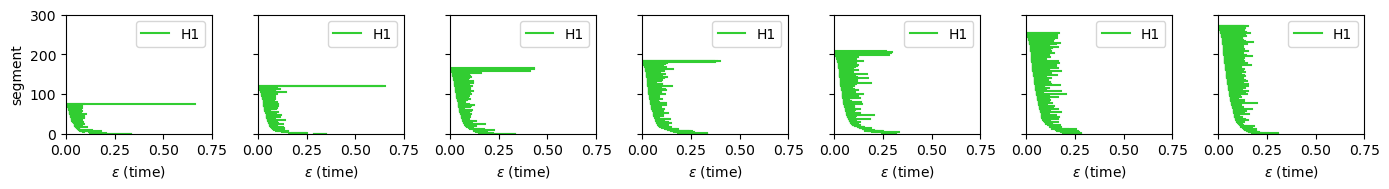

In [83]:
clusters2show = ALL
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    i = ALL.index(k)
    barc = barcs2[i]
    ax[col].set_ylim(0, 300)
    ax[col].set_xlim(0, 0.75)
    barcodes.plot_barcodes(barcodes.barc2array(barc), title = '', ax = ax[col], fig = fig)
    
    if col > 0:
        ax[col].set_ylabel('')
        
    ax[col].legend(loc = 'best')
    
fig.tight_layout()
plt.show()

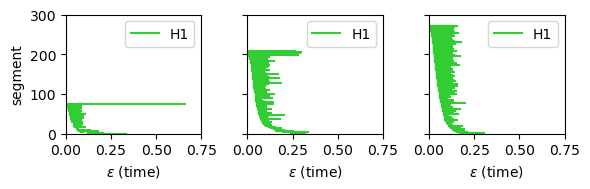

In [84]:
clusters2show = [2, 6, 12]
cols = len(clusters2show)

fig, ax = plt.subplots(1, cols, sharey = True)
fig.set_size_inches((2 * cols, 2))

for col, k in enumerate(clusters2show):
    i = ALL.index(k)
    barc = barcs2[i]
    ax[col].set_ylim(0, 300)
    ax[col].set_xlim(0, 0.75)
    barcodes.plot_barcodes(barcodes.barc2array(barc), title = '', ax = ax[col], fig = fig)
    
    if col > 0:
        ax[col].set_ylabel('')
        
    ax[col].legend(loc = 'best')
    
fig.tight_layout()
plt.show()

In [85]:
res_total = 0.5 * (np.array(res1) + np.array(res2))

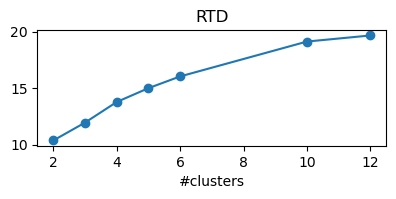

In [86]:
clusters_list = [2, 3, 4, 5, 6, 10, 12]

fig, ax = plt.subplots(1, 1)
fig.set_size_inches((4.5, 1.5))
plt.plot(clusters_list, res_total[:len(clusters_list)], 'o-', label = 'base/mod')
ax.set_xlabel('#clusters')
plt.title('RTD')
plt.show()

In [87]:
stats.kendalltau(res_total, clusters_list).correlation

1.0

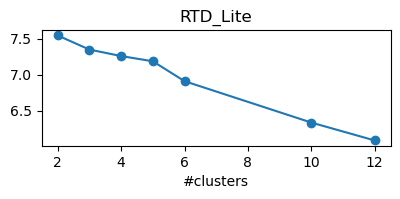

In [88]:
clusters_list = [2, 3, 4, 5, 6, 10, 12]

fig, ax = plt.subplots(1, 1)
fig.set_size_inches((4.5, 1.5))
plt.plot(clusters_list, res_rtd_lite1[:len(clusters_list)], 'o-', label = 'base/mod')
ax.set_xlabel('#clusters')
plt.title('RTD_Lite')
plt.show()

In [89]:
stats.kendalltau(res_rtd_lite1, clusters_list).correlation

-1.0

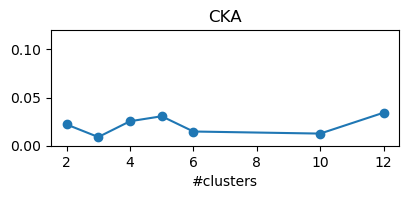

In [90]:
fig, ax = plt.subplots(1, 1)

fig.set_size_inches((4.5, 1.5))
ax.set_xlabel('#clusters')
ax.set_ylim(0.0, 0.12)
plt.title('CKA')
plt.plot(clusters_list, res_cka[:len(clusters_list)], 'o-')
plt.show()

In [91]:
stats.kendalltau(res_cka, clusters_list).correlation

0.23809523809523814